<a href="https://colab.research.google.com/github/v1nokuroff/drag-and-drop-feature/blob/main/%D0%A1%D0%98%D0%98_%D0%A2%D0%B5%D1%82%D1%80%D0%B0%D0%B4%D1%8C_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Пусть дана начальная популяция из четырех хромосом с двумя генами х и у.
Показатель качества хромосомы оценивается функцией Z = (x - 3*y + 1) / (3*x^2 + 3*y^2 + 1).
При равном качестве хромосом предпочтение отдается хромосоме с большим номером.
На каждом этапе хромосома с высшим качеством порождает четыре новых хромосомы,
обмениваясь генами с двумя хромосомами более низкого качества.
Последняя хромосома (с низшим качеством) выбывает из популяции.

# ПОЧЕМУ МАКСИМУМ ОТЛИЧАЕТСЯ ОТ ЗНАЧЕНИЙ, ПОЛУЧАЕМЫХ НА РАЗНЫХ ШАГАХ

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from math import exp

def qZ(x, y):
    """Функция качества хромосомы"""
    return (x - 3*y + 1) / (3*x**2 + 3*y**2 + 1)

def qSumZ(Z):
    """Суммарное качество всех хромосом"""
    return sum(Z)

def exchangeScheme(oldx, oldy, sortedId):
    """Схема обмена генами между хромосомами"""
    X = [0 for i in range(4)]
    Y = [0 for i in range(4)]
    X[2] = oldx[sortedId[2]]
    X[3] = oldx[sortedId[2]]
    X[0] = oldx[sortedId[0]]
    X[1] = oldx[sortedId[1]]
    Y[0] = oldy[sortedId[2]]
    Y[1] = oldy[sortedId[2]]
    Y[2] = oldy[sortedId[0]]
    Y[3] = oldy[sortedId[1]]
    return X, Y

def sorting(Z):
    """Сортировка массива качества и возврат индексов"""
    sortedId = sorted(range(len(Z)), key=lambda k: Z[k])
    return sortedId

def evoStep(X, Y, Z):
    """Один шаг эволюции - удаление худшей хромосомы"""
    _, minId = min((value, id) for (id, value) in enumerate(Z))
    X = X[:]
    Y = Y[:]
    Z = Z[:]
    X.pop(minId)
    Y.pop(minId)
    Z.pop(minId)
    return X, Y, Z

# Основная эволюционная функция
def evoSteps(X, Y, stepsNum=4):
    """
    Выполняет заданное количество шагов эволюции
    Возвращает итоговые популяции и историю результатов
    """
    results = []
    currentX = X[:]
    currentY = Y[:]

    for step in range(stepsNum):
        # Оценка качества
        Z = [qZ(currentX[i], currentY[i]) for i in range(len(currentX))]
        total_quality = qSumZ(Z)

        # Удаление худшей хромосомы
        newX, newY, newZ = evoStep(currentX, currentY, Z)

        # Схема обмена
        sortedId = sorting(newZ)
        newX, newY = exchangeScheme(newX, newY, sortedId)

        # Сохранение результатов
        results.append({
            'step': step + 1,
            'X': newX.copy(),
            'Y': newY.copy(),
            'total_quality': total_quality,
            'individual_quality': Z.copy()
        })

        currentX = newX
        currentY = newY

    return currentX, currentY, results


# Вариант 7
print("=" * 60)
print("ЧАСТЬ 1: ГЕНЕТИЧЕСКИЙ АЛГОРИТМ")
print("=" * 60)

# Начальные данные
X = [-5, -3, -2, 0]
Y = [-1, -2, 0, 1]

print(f"\nНачальная популяция:")
for i in range(len(X)):
    print(f"  Хромосома {i+1}: x = {X[i]}, y = {Y[i]}, quality = {qZ(X[i], Y[i]):.6f}")

# Запуск эволюции
finalX, finalY, history = evoSteps(X, Y, stepsNum=4)

print(f"\n" + "=" * 40)
print("Результаты эволюции:")
print("=" * 40)

# Вывод результатов по шагам
for result in history:
    print(f"\nШаг {result['step']}:")
    print(f"  Максимальное качество в популяции: {max(result['individual_quality']):.8f}")
    print(f"  Общее качество популяции: {result['total_quality']:.8f}")
    print(f"  Популяция X: {result['X']}")
    print(f"  Популяция Y: {result['Y']}")

print(f"\n" + "=" * 40)
print("Итоговые результаты после 4 шагов:")
print("=" * 40)
print(f"Финальная популяция X: {finalX}")
print(f"Финальная популяция Y: {finalY}")

# Сбор всех качеств за все шаги
all_qualities = []
for result in history:
    all_qualities.extend(result['individual_quality'])

print(f"\nМаксимальный показатель качества хромосомы за все время: {max(all_qualities):.8f}")


ЧАСТЬ 1: ГЕНЕТИЧЕСКИЙ АЛГОРИТМ

Начальная популяция:
  Хромосома 1: x = -5, y = -1, quality = -0.012658
  Хромосома 2: x = -3, y = -2, quality = 0.100000
  Хромосома 3: x = -2, y = 0, quality = -0.076923
  Хромосома 4: x = 0, y = 1, quality = -0.500000

Результаты эволюции:

Шаг 1:
  Максимальное качество в популяции: 0.10000000
  Общее качество популяции: -0.48958130
  Популяция X: [-2, -5, -3, -3]
  Популяция Y: [-2, -2, 0, -1]

Шаг 2:
  Максимальное качество в популяции: 0.20000000
  Общее качество популяции: 0.18355677
  Популяция X: [-5, -3, -2, -2]
  Популяция Y: [-2, -2, -2, -1]

Шаг 3:
  Максимальное качество в популяции: 0.20000000
  Общее качество популяции: 0.44772727
  Популяция X: [-3, -2, -2, -2]
  Популяция Y: [-2, -2, -2, -1]

Шаг 4:
  Максимальное качество в популяции: 0.20000000
  Общее качество популяции: 0.62500000
  Популяция X: [-2, -2, -2, -2]
  Популяция Y: [-2, -2, -1, -2]

Итоговые результаты после 4 шагов:
Финальная популяция X: [-2, -2, -2, -2]
Финальная поп

КАК БУДЕТ МЕНЯТЬСЯ МОДЕЛЬ В ЗАВИСИМОСТИ ОТ ИЗМЕНЕНИЯ ПАРАМЕТРОВ


ЧАСТЬ 2: МЕТОД ИМИТАЦИИ ОТЖИГА

Начальный маршрут: [1, 4, 5, 2, 6, 3, 1]
Начальная длина маршрута: 189
Начальная температура: 100

--------------------------------------------------

Шаг 1:
  Замена вершин: (3, 4)
  Новый маршрут: [1, 4, 2, 5, 6, 3, 1]
  Новая длина: 209
  ΔS = +20
  Вероятность принятия: 81.87%
  Случайное число P = 49
  Решение: ПРИНЯТО (ухудшение, но разрешено)
  Новая температура: 50.0

Шаг 2:
  Замена вершин: (4, 6)
  Новый маршрут: [1, 4, 2, 3, 6, 5, 1]
  Новая длина: 186
  ΔS = -23
  Вероятность принятия: 100.00%
  Случайное число P = 54
  Решение: ПРИНЯТО (улучшение)
  Новая температура: 25.0

Шаг 3:
  Замена вершин: (5, 2)
  Новый маршрут: [1, 6, 2, 3, 4, 5, 1]
  Новая длина: 146
  ΔS = -40
  Вероятность принятия: 100.00%
  Случайное число P = 43
  Решение: ПРИНЯТО (улучшение)
  Новая температура: 12.5

Шаг 4:
  Замена вершин: (6, 2)
  Новый маршрут: [1, 5, 2, 3, 4, 6, 1]
  Новая длина: 166
  ΔS = +20
  Вероятность принятия: 20.19%
  Случайное число P = 54
  

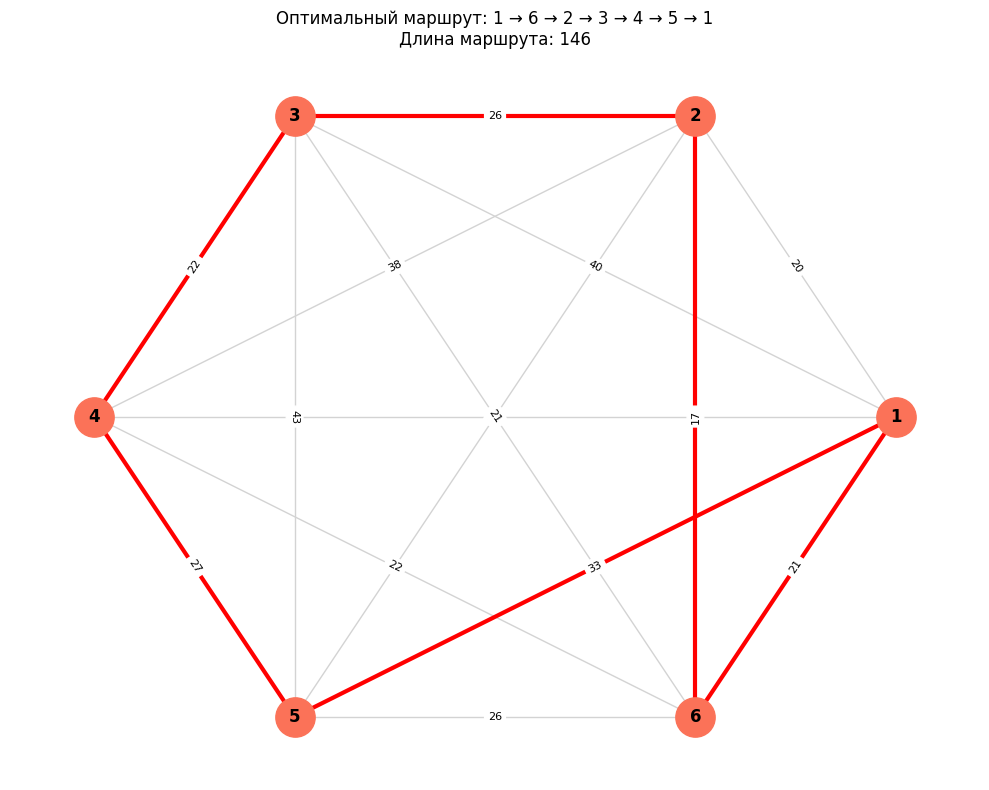

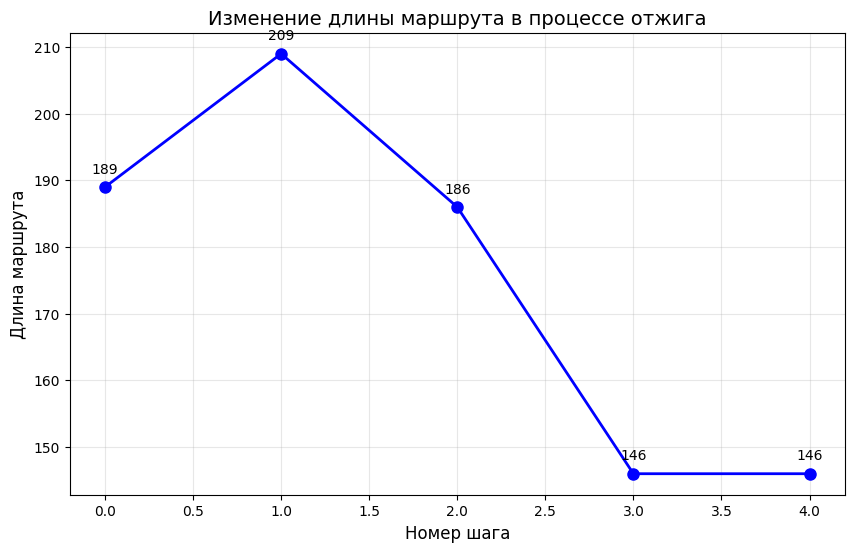

In [ ]:

print("\n" + "=" * 60)
print("ЧАСТЬ 2: МЕТОД ИМИТАЦИИ ОТЖИГА")
print("=" * 60)

# Вариант 7
distances = [
    (1, 2, 24), (1, 3, 41), (1, 4, 36), (1, 5, 22), (1, 6, 19),
    (2, 3, 21), (2, 4, 33), (2, 5, 33), (2, 6, 14),
    (3, 4, 27), (3, 5, 39), (3, 6, 23),
    (4, 5, 20), (4, 6, 20),
    (5, 6, 19)
]

# Начальная последовательность вершин
V = [1, 3, 4, 5, 6, 2, 1]

# Последовательности замен вершин
Z = [(3, 4), (4, 6), (5, 2), (6, 2)]

# Выпавшие вероятности перехода
P = [33, 82, 51, 76]

# Начальная температура
T0 = 100

# Функция вероятности перехода
def probability(delta, T):
    """Вероятность принятия худшего решения"""
    if delta <= 0:
        return 100
    return 100 * exp(-delta / T)

# Функция изменения температуры
def reduceTemp(prevT):
    """Закон снижения температуры"""
    return 0.5 * prevT

# Вычисление длины ребра
def edgeLength(i, j, distances):
    """Находит длину ребра между вершинами i и j"""
    for item in distances:
        if (item[0] == i and item[1] == j) or (item[1] == i and item[0] == j):
            return item[2]
    return float('inf')

# Вычисление длины маршрута
def routeLength(route, distances):
    """Вычисляет полную длину маршрута"""
    length = 0
    for i in range(len(route) - 1):
        length += edgeLength(route[i], route[i + 1], distances)
    return length

# Одна перестановка в пути
def routeOneReplacement(route, swap_pair):
    """Меняет местами две вершины в маршруте"""
    new_route = route.copy()
    i, j = swap_pair[0] - 1, swap_pair[1] - 1  # перевод в 0-индексацию
    new_route[i], new_route[j] = new_route[j], new_route[i]
    return new_route

# Основной алгоритм имитации отжига
def simulatedAnnealing(distances, initial_route, swaps, P, T0):
    """
    Реализация метода имитации отжига
    Возвращает лучший найденный маршрут и историю длин
    """
    current_route = initial_route.copy()
    current_length = routeLength(current_route, distances)

    history_lengths = [current_length]
    temperature = T0

    print(f"\nНачальный маршрут: {current_route}")
    print(f"Начальная длина маршрута: {current_length}")
    print(f"Начальная температура: {temperature}")
    print("\n" + "-" * 50)

    for i, swap in enumerate(swaps):
        # Генерируем новый маршрут
        new_route = routeOneReplacement(current_route, swap)
        new_length = routeLength(new_route, distances)

        delta = new_length - current_length
        p = probability(delta, temperature)

        print(f"\nШаг {i+1}:")
        print(f"  Замена вершин: {swap}")
        print(f"  Новый маршрут: {new_route}")
        print(f"  Новая длина: {new_length}")
        print(f"  ΔS = {delta:+d}")
        print(f"  Вероятность принятия: {p:.2f}%")
        print(f"  Случайное число P = {P[i]}")

        # Решение о принятии нового маршрута
        if delta <= 0:
            # Улучшение - принимаем всегда
            current_route = new_route
            current_length = new_length
            print(f"  Решение: ПРИНЯТО (улучшение)")
        elif p > P[i]:
            # Ухудшение, но принимаем с вероятностью
            current_route = new_route
            current_length = new_length
            print(f"  Решение: ПРИНЯТО (ухудшение, но разрешено)")
        else:
            print(f"  Решение: ОТКЛОНЕНО")

        # Снижение температуры
        temperature = reduceTemp(temperature)
        print(f"  Новая температура: {temperature:.1f}")

        history_lengths.append(current_length)

    return current_route, history_lengths


# Решение задачи
best_route, history_lengths = simulatedAnnealing(distances, V, Z, P, T0)

print("\n" + "=" * 50)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ:")
print("=" * 50)
print(f"Лучший выбранный маршрут: {best_route}")
print(f"Длина лучшего маршрута: {routeLength(best_route, distances)}")
print(f"История длин маршрутов: {history_lengths}")

# Визуализация графа с лучшим маршрутом
def draw_route_graph(distances, route):
    """Отрисовка графа с выделенным маршрутом"""
    # Создаем полный граф
    G = nx.Graph()
    for d in distances:
        G.add_edge(d[0], d[1], weight=d[2])

    # Создаем подграф с ребрами маршрута
    route_edges = []
    for i in range(len(route) - 1):
        route_edges.append((route[i], route[i+1]))

    plt.figure(figsize=(10, 8))
    pos = nx.circular_layout(G)

    # Рисуем все ребра (светло-серые)
    nx.draw_networkx_edges(G, pos, edge_color='lightgray', width=1)

    # Рисуем ребра маршрута (красные, жирные)
    nx.draw_networkx_edges(G, pos, edgelist=route_edges, edge_color='red', width=3)

    # Рисуем вершины
    nx.draw_networkx_nodes(G, pos, node_color='#fb7258', node_size=800)
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

    # Добавляем подписи весов ребер
    edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title(f"Оптимальный маршрут: {' → '.join(map(str, route))}\nДлина маршрута: {routeLength(route, distances)}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Рисуем граф с лучшим маршрутом
draw_route_graph(distances, best_route)

# График изменения длины маршрута
plt.figure(figsize=(10, 6))
plt.plot(range(len(history_lengths)), history_lengths, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Номер шага', fontsize=12)
plt.ylabel('Длина маршрута', fontsize=12)
plt.title('Изменение длины маршрута в процессе отжига', fontsize=14)
plt.grid(True, alpha=0.3)
for i, length in enumerate(history_lengths):
    plt.annotate(str(length), (i, length), textcoords="offset points", xytext=(0, 10), ha='center')
plt.show()



